In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def MP_processor(image):
    B=[]
    list_img_90=list(sum(np.rot90(image)))
    for i in range(len(list_img_90)):
        if list_img_90[i]==0:
            pass
        elif list_img_90[i]!=0:
            list_img_90[i]=1
    for i in range(len(list_img_90)):
        if i==0:
            pass 
        elif list_img_90[i]==list_img_90[i-1]:
            pass
        elif list_img_90[i]!=list_img_90[i-1]:
            B.append(i)
    center=round((B[1]+B[2])/2)
    ##print(B) #len(B) should be 4
    img_L=image.copy()
    img_R=image.copy()
    img_L[center:]=0
    img_R[0:center]=0
    return img_R,img_L

def get_coor(image):
    A,B=[],[]
    list_img=list(sum(image))
    list_img_90=list(sum(np.rot90(image)))
    for i in range(len(list_img)):
        if list_img[i]==0:
            pass
        elif list_img[i]!=0:
            A.append(i)
    for j in range(len(list_img_90)):
        if list_img_90[j]==0:
            pass
        elif list_img_90[j]!=0:
            B.append(j)
    x1,x2=min(B),max(B)
    y1,y2=min(A),max(A)
    return x1,x2,y1,y2

def to_yolo(mask):
    length,height=image.shape
    y1,y2,x1,x2 = get_coor(mask) ## the coordinations of numpy and yolo are different, x axis is verticle in numpy while horizental in yolo
    yolo_mid_x=round((x1+x2)/2)/length
    yolo_mid_y=round((y1+y2)/2)/height
    yolo_dx=round(abs(x1-x2))/length
    yolo_dy=round(abs(y1-y2))/height
    return yolo_mid_x,yolo_mid_y,yolo_dx,yolo_dy

def yolo_txt_MP(image,path):
    a,b = MP_processor(image)
    f=open(path,'w')
    lines=[str(x)+' ' for x in [0]+list(to_yolo(a))]+['\n']+[str(y)+' ' for y in [0]+list(to_yolo(b))]
    f.writelines(lines)
    f.close()
    return

def operator(root_filepath,output_filepath):
    file_name_list=os.listdir(root_filepath)
    file_path_list=[]
    for i in range(len(file_name_list)):
        file_path_list.append(os.path.join(root_filepath,file_name_list[i]))
    #print(file_path_list)
    for i in range(len(file_path_list)):
        image=cv2.imread(file_path_list[i],0)>=50
        path=os.path.join(output_filepath,str(file_name_list[i][:-4])+'.txt')
        yolo_txt_MP(image,path)
    return

NameError: name 'image' is not defined

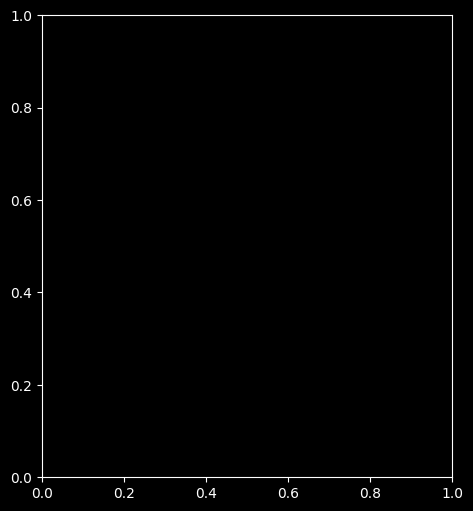

In [4]:
## KP/KPH Usage

fig=plt.figure(figsize=(18,6))
plt.subplot(131),plt.imshow(image,cmap='gray')
plt.subplot(132),plt.imshow(np.rot90(image),cmap='gray')

x1,x2,y1,y2 = get_coor(image)

image2 = image.copy()
image2[x1:x2,y1:y2]=255
print(to_yolo(a),to_yolo(b))

plt.subplot(133),plt.imshow(image,cmap='gray'),plt.imshow(image2,cmap='gray',alpha=0.7)

(0.412109375, 0.5771484375, 0.3173828125, 0.111328125) (0.40625, 0.392578125, 0.3203125, 0.0859375)


(<AxesSubplot: >,
 <matplotlib.image.AxesImage at 0x195208c8e20>)

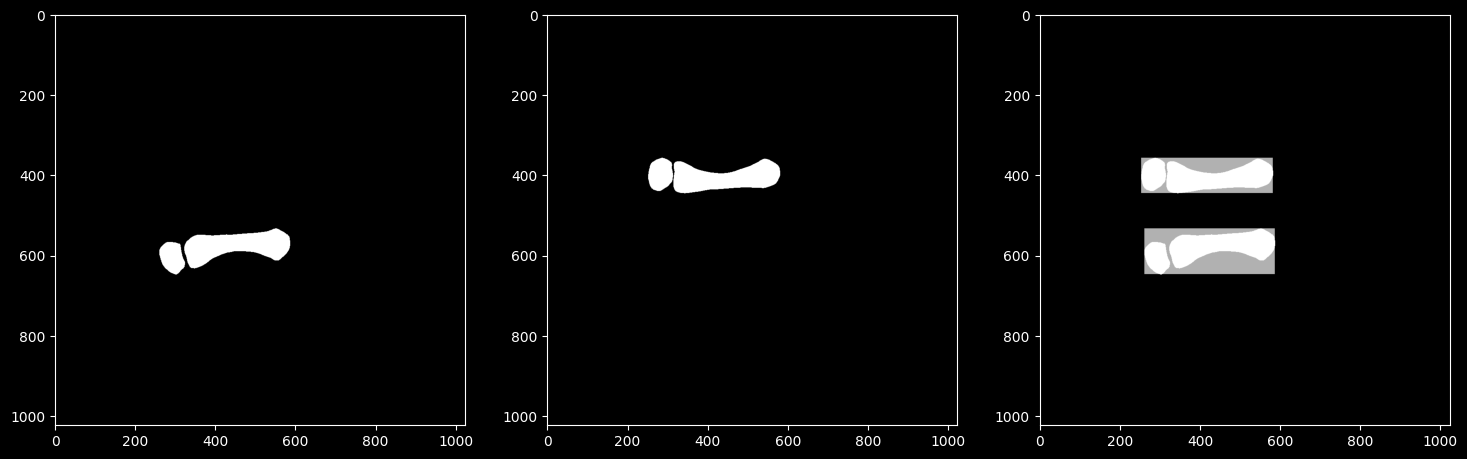

In [4]:
##MP Usage
#image = cv2.imread(r'D:\0A_lab_data\Code\Unet\20241110_2\masks\0.jpg',0)>=10
image = cv2.imread(r'D:\0A_lab_data\Code\Unet\20241110_2\masks\404.jpg',0)>=50
#image = cv2.imread(r'D:\0A_lab_data\Code\Unet\20241110_2\masks\N33MP02_0036.jpg',0)>=50
a,b = MP_processor(image)

xl1,xl2,yl1,yl2 = get_coor(a)
xr1,xr2,yr1,yr2 = get_coor(b)

image2 = image.copy()
image2[xl1:xl2,yl1:yl2]=255
image2[xr1:xr2,yr1:yr2]=255

print(to_yolo(a),to_yolo(b))


fig=plt.figure(figsize=(18,6))
plt.subplot(131),plt.imshow(a,cmap='gray')
plt.subplot(132),plt.imshow(b,cmap='gray')
plt.subplot(133),plt.imshow(image,cmap='gray'),plt.imshow(image2,cmap='gray',alpha=0.7)

In [7]:
operator(r'D:\0A_lab_data\Code\Unet\test',r'D:\0A_lab_data\Code\Unet\test_output')

## labelme to yolo

In [11]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json

image_path=r'temp\20241025\image'
label_path=r'temp\20241025\label'
txt_path=r'temp\20241025\txt'
output_path=r'temp\20241025\output_txt'
List=[]
for i in [image_path,label_path,txt_path]:
    l=[]
    for j in os.listdir(i):
        l.append(os.path.join(i,j))
    List.append(l)
name_list=[]
for i in range(len(List[0])):
    name_list.append(os.path.join(output_path,List[0][i].split('.')[0].split('\\')[-1]+str('.txt')))

In [12]:
#def get_data(image_path,label_path,txt_path):
    #image=cv2.imread(image_path,0)
    #txt=open(txt_path,'r')
    #line = txt.read()
    #txt.close()
    #plt.imshow(image,cmap='gray')
    #print(line)
    #return

def get_data(image_path,label_path,txt_path):
    #image=cv2.imread(image_path,0)
    #plt.imshow(image,cmap='gray')
    kypts_r,kypts_l = read_label(label_path)
    bbox_r,bbox_l = read_txt(txt_path)
    return bbox_r+kypts_r,bbox_l+kypts_l

def read_txt(filepath): ## input: txt_filepath
    f=open(filepath,'r')
    content=[]
    for i in f.readlines():
        content.append(i)
    f.close()
    content[0]=content[0].split('\n')[0]
    #for i in range(len(content)):
        #content[i]=content[i].split(' ')[:-1]
    return content ## output: MP=2 series of coordinate / KP=1 gourp of coordinate

def read_label(filepath): ## input: labelme json file
    f=open(filepath)
    jdata=json.load(f)
    f.close
    kypts_r,kypts_l=labelmeCoor_YoloCoor(jdata)
    return kypts_r,kypts_l

def labelmeCoor_YoloCoor(json):
    image_height,image_width=json['imageHeight'],json['imageWidth']
    kypts=[]
    for i in range(len(json['shapes'])):
        K=''
        #print(json['shapes'][i]['points'])
        for j in range(len(json['shapes'][i]['points'])):
            k=''
            #print(json['shapes'][i]['points'][j])
            x,y=json['shapes'][i]['points'][j][0]/image_width,json['shapes'][i]['points'][j][1]/image_height
            #print(x,y)
            k=k+str(x)+str(' ')+str(y)+str(' ')+str('2')+str(' ')
            #print(k)
            K=K+k
        #print(K)
        kypts.append(K)
    #print(kypts)
    return kypts

def MP_txt_output(List,name_list):
    for i in range(len(List[0])):
        a,b = get_data(List[0][i],List[1][i],List[2][i])
        f=open(name_list[i],'w')
        lines=a+str('\n')+b
        f.writelines(lines)
        f.close()
    return

MP_txt_output(List,name_list)

## Shuffle dataset

In [12]:
##auto_shuffle tool

import random
import os
import numpy as np
import shutil

Img_root=r'D:\0A_lab_data\Code\Unet\dataset\raw\image'
mask_root=r'D:\0A_lab_data\Code\Unet\dataset\raw\MP_all\segmentation\Conbine'
Label_root=r'D:\0A_lab_data\Code\Unet\dataset\raw\yolo_label'
output_root=r'D:\0A_lab_data\Code\Unet\temp\shuffle'

train_img_fp = os.path.join(output_root,'images\\train')
val_img_fp = os.path.join(output_root,'images\\val')
train_label_fp = os.path.join(output_root,'labels\\train')
val_label_fp = os.path.join(output_root,'labels\\val')
if os.path.isdir(output_root):
    shutil.rmtree(output_root) ##刪除output資料夾
    for i in [train_img_fp,val_img_fp,train_label_fp,val_label_fp]:
        os.makedirs(i)
else:
    #os.makedirs(output_root)
    for i in [train_img_fp,val_img_fp,train_label_fp,val_label_fp]:
        os.makedirs(i)

L = os.listdir(Img_root)
L2 = os.listdir(Label_root)
a = [*range(len(L))]
random.shuffle(a)

train_I=[]
val_I=[]
train_L=[]
val_L=[]

for i in range(len(a)):
    if i<=0.1*len(L):
        shutil.copyfile(os.path.join(Img_root,L[a[i]]),os.path.join(val_img_fp,L[a[i]]))
        shutil.copyfile(os.path.join(Label_root,L2[a[i]]),os.path.join(val_label_fp,L2[a[i]]))
    else:
        shutil.copyfile(os.path.join(Img_root,L[a[i]]),os.path.join(train_img_fp,L[a[i]]))
        shutil.copyfile(os.path.join(Label_root,L2[a[i]]),os.path.join(train_label_fp,L2[a[i]]))
